## Reproductible fitting for the `jmstate` package

In [10]:
%pip install -q jmstate==0.17.2 pandas seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.float_format", "{:.3f}".format)

In [12]:
from jmstate import MultiStateJointModel
from jmstate.types import SampleData
from torch.distributions import MultivariateNormal


def pk_fn(t: torch.Tensor, indiv_params: torch.Tensor, D: float = 1.0):
    A, k, ka = indiv_params.chunk(3, dim=-1)
    conc = A * (torch.exp(-k * t) - torch.exp(-ka * t))
    return conc.unsqueeze(-1)


def pk_integral_fn(t: torch.Tensor, indiv_params: torch.Tensor):
    A, k, ka = indiv_params.chunk(3, dim=-1)
    integral = A * (
        (1.0 / k) * (1 - torch.exp(-k * t)) - (1.0 / ka) * (1 - torch.exp(-ka * t))
    )
    return integral.unsqueeze(-1)


def indiv_params_fn(fixed: torch.Tensor, x: torch.Tensor, b: torch.Tensor):
    return fixed * b.exp()


def gen_data(n: int, m: int, true_model: MultiStateJointModel):
    # Censoring times
    c = torch.rand(n, 1) * 5 + 10

    # Covariates
    x = torch.randn(n, 4)

    # Latent and noise distributions
    random_prec = true_model.params.random_prec.precision.detach()
    noise_prec = true_model.params.noise_prec.precision.detach()
    random_dist = MultivariateNormal(
        torch.zeros(random_prec.size(0)), precision_matrix=random_prec
    )
    noise_dist = MultivariateNormal(
        torch.zeros(noise_prec.size(0)), precision_matrix=noise_prec
    )

    # Individual parameters
    b = random_dist.sample((n,))
    indiv_params = true_model.design.indiv_params_fn(
        true_model.params.fixed_effects.detach(), x, b
    )

    # Defines initial state for individuals
    trajectories_init = [[(0.0, 1)] for _ in range(n)]

    # Samples trajectories
    sample_data = SampleData(x[:, [0]], trajectories_init, indiv_params)
    trajectories = true_model.sample_trajectories(sample_data, c)

    # Samples longitudinal values
    t = torch.linspace(0, 15, m)
    y = design.regression_fn(t, indiv_params)
    y += noise_dist.sample(y.shape[:2])

    # Censors longitudinal measurements exceeding censoring times
    y[t > c] = torch.nan

    return x, t, y, trajectories, c

In [13]:
from jmstate.types import ModelDesign

# Survival model specification
surv_fns = {(1, 1): pk_integral_fn, (1, 2): pk_integral_fn}

# Model design gathers regression, link and hazard functions
design = ModelDesign(indiv_params_fn, pk_fn, surv_fns)

In [14]:
from jmstate.functions.base_hazards import Exponential
from jmstate.types import ModelParameters, PrecisionParameters

# Gaussian means
fixed_effects = torch.tensor([2.0, 0.2, 1.0])

# Covariance matrices
random_prec = PrecisionParameters.from_covariance(
    torch.diag(torch.tensor([0.15, 0.05, 0.1])), "diag"
)
noise_prec = PrecisionParameters.from_covariance(torch.tensor([[0.05]]), "spherical")

# Base hazard functions
base_hazards = {(1, 1): Exponential(2e-1), (1, 2): Exponential(1e-2)}

# Link parameters
link_coefs = {(1, 1): torch.tensor([-1.0]), (1, 2): torch.tensor([0.5])}

# Covariate parameters
x_coefs = {(1, 1): torch.tensor([-1.0]), (1, 2): torch.tensor([0.5])}

# Instance declaration
true_parameters = ModelParameters(
    fixed_effects,
    random_prec,
    noise_prec,
    base_hazards,
    link_coefs,
    x_coefs,
)

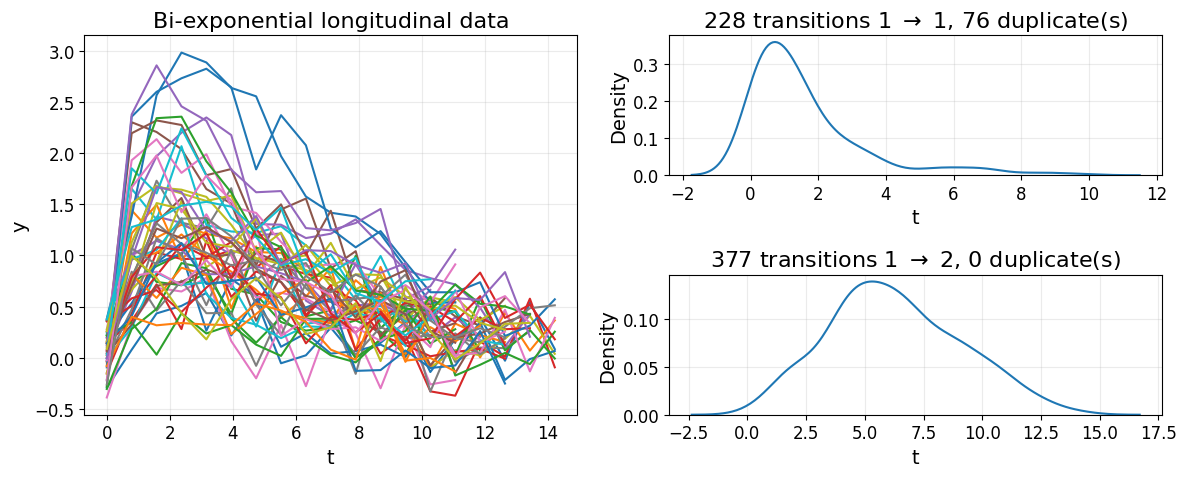

In [15]:
import seaborn as sns
from jmstate.types import ModelData
from jmstate.utils import build_buckets

# Declare the true underlying model
true_model = MultiStateJointModel(design, true_parameters)

# Generate data
torch.manual_seed(42)
data = ModelData(*gen_data(500, 20, true_model))
data.x = data.x[:, [0]]

buckets = build_buckets(data.trajectories)

with plt.rc_context(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
):
    fig = plt.figure(figsize=(12, 5))

    ax_left = fig.add_subplot(1, 2, 1)
    ax_left.plot(data.t, data.y[:50, ..., 0].T)
    ax_left.set_title("Bi-exponential longitudinal data")
    ax_left.set_xlabel("t")
    ax_left.set_ylabel("y")
    ax_left.grid(alpha=0.25)

    for i, (key, (idxs, _, t1)) in enumerate(buckets.items()):
        ax_right = fig.add_subplot(2, 2, 2 + 2 * i)
        n = idxs.numel() - torch.unique(idxs).numel()

        sns.kdeplot(t1.numpy().ravel(), ax=ax_right)
        ax_right.set_title(
            rf"{idxs.numel()} transitions {key[0]} $\to$ {key[1]}, {n} duplicate(s)"
        )
        ax_right.set_xlabel("t")
        ax_right.set_ylabel("Density")
        ax_right.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig("../figures/simulated-sample.pdf")
    plt.show()

In [16]:
# Declares initial parameters; zero mean and unit variance
def init_params_correct():
    return ModelParameters(
        torch.ones(3),
        PrecisionParameters.from_covariance(torch.eye(3), "diag"),
        PrecisionParameters.from_covariance(torch.eye(1), "spherical"),
        {(1, 1): Exponential(1.0), (1, 2): Exponential(1.0)},
        {k: torch.zeros_like(v) for k, v in link_coefs.items()},
        {k: torch.zeros_like(v) for k, v in x_coefs.items()},
    )


# Misspecified parameters (too few)
def init_params_less():
    shared_coef = torch.nn.Parameter(torch.zeros(1))
    return ModelParameters(
        torch.ones(3),
        PrecisionParameters.from_covariance(torch.eye(3), "diag"),
        PrecisionParameters.from_covariance(torch.eye(1), "spherical"),
        {(1, 1): Exponential(1.0), (1, 2): Exponential(1.0)},
        {k: shared_coef for k, v in link_coefs.items()},
        {k: torch.zeros_like(v) for k, v in x_coefs.items()},
    )


# Misspecified parameters (too many)
def init_params_more():
    return ModelParameters(
        torch.ones(3),
        PrecisionParameters.from_covariance(torch.eye(3), "diag"),
        PrecisionParameters.from_covariance(torch.eye(1), "spherical"),
        {(1, 1): Exponential(1.0), (1, 2): Exponential(1.0)},
        {k: torch.zeros_like(v) for k, v in link_coefs.items()},
        {k: torch.zeros(4) for k, v in x_coefs.items()},
    )


# Misspecified model design
design_mis = ModelDesign(indiv_params_fn, pk_fn, dict.fromkeys(surv_fns, pk_fn))

In [17]:
# Declares and fits the model
torch.manual_seed(42)
params = init_params_correct()
optimizer = torch.optim.Adam(params.parameters(), lr=0.1)
model = MultiStateJointModel(design, params, optimizer).fit(data)

Fitting joint model:  53%|█████▎    | 526/1000 [00:16<00:15, 31.11it/s]


Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:06<00:00, 16.13it/s]


╭──────────────────────────────────────────── Model Summary ─────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name                  ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ fixed_effects[0]                │ 2.051  │     0.059      │ 34.740  │  0.000  │        ***         │ │
│ │ fixed_effects[1]                │ 0.198  │     0.004      │ 53.845  │  0.000  │        ***         │ │
│ │ fixed_effects[2]                │ 1.000  │     0.030      │ 32.869  │  0.000  │        ***         │ │
│ │ random_prec.flat[0]             │ 0.907  │     0.049      │ 18.565  │  0.000  │        ***         │ │
│ │ random_prec.flat[1]             │ 1.549  │     0.072      │ 21.491  │  0.000  │        ***         │ │
│ │ random_prec.flat[2]             │ 1.031  │     0.069      │ 14.973  │  0.000  │        ***         │ │
│ │ noise_prec.flat[0]              │ 1.493  │     0.008      │ 176.189 │  0.000  │        ***         │ │
│ │ base_hazards.(1, 1).log_lmda[0] │ -1.681 │     0.106      │ 15.885  │  0.000  │        ***         │ │
│ │ base_hazards.(1, 2).log_lmda[0] │ -4.449 │     0.146      │ 30.437  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 1)[0]            │ -0.910 │     0.066      │ 13.731  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 2)[0]            │ 0.484  │     0.025      │ 19.109  │  0.000  │        ***         │ │
│ │ x_coefs.(1, 1)[0]               │ -0.974 │     0.085      │ 11.431  │  0.000  │        ***         │ │
│ │ x_coefs.(1, 2)[0]               │ 0.530  │     0.061      │  8.722  │  0.000  │        ***         │ │
│ └─────────────────────────────────┴────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: -2160.518                                                                              │
│ AIC: 4347.037                                                                                          │
│ BIC: 4407.191                                                                                          │
│ ────────────────────────────────────────────────────────────────────────────────────────────────────── │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

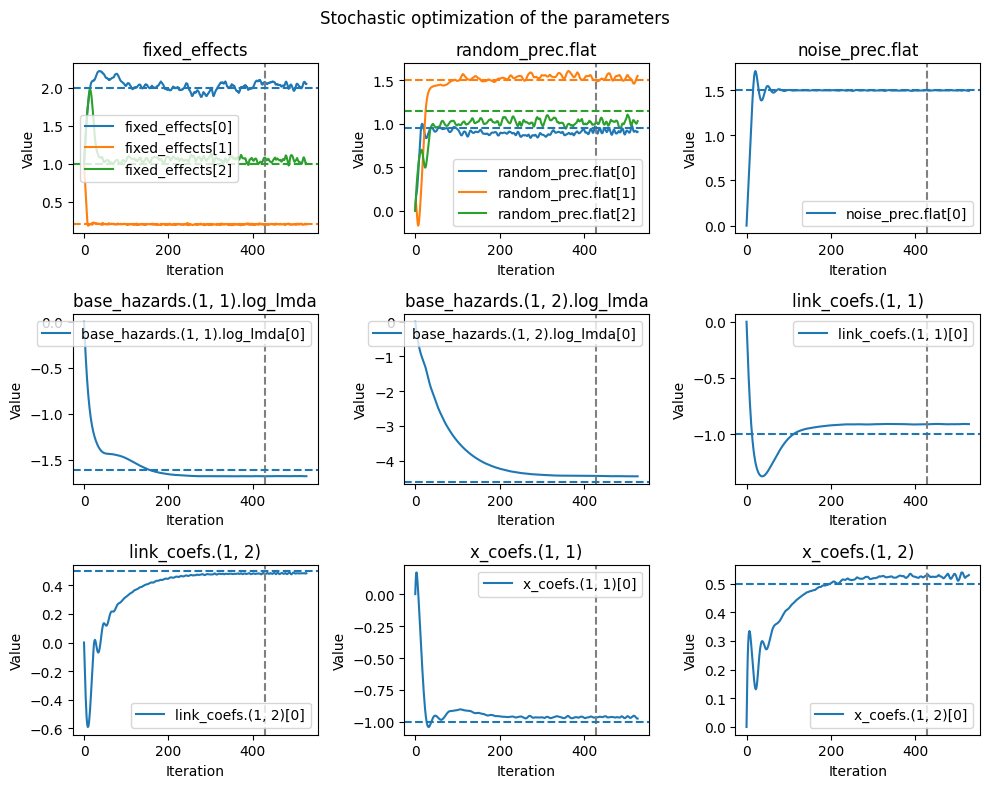

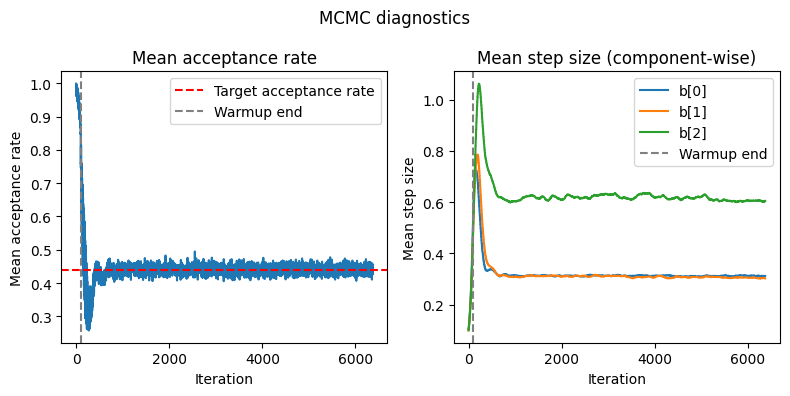

In [ ]:
from jmstate.utils import plot_mcmc_diagnostics, plot_params_history

model.compute_summary().summary()

fig, axes = plot_params_history(model)

# Add true parameters
conv = len(model.params_history_) - model.window_size
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for ax, param in zip(list(axes), true_parameters.parameters(), strict=False):
    ax.axvline(x=conv, c="gray", linestyle="--")
    for i, p in enumerate(param.flatten()):
        ax.axhline(y=p.detach(), c=colors[i], linestyle="--")

plt.savefig("../figures/simulated-optimization.pdf")
plt.show()

plot_mcmc_diagnostics(model)
plt.savefig("../figures/simulated-diagnostics.pdf")
plt.show()

In [ ]:
from dataclasses import replace

from torch.nn.utils import parameters_to_vector
from tqdm import trange


def get_vector_and_scores(parameters_factory, design, data):
    parameters = parameters_factory()
    optimizer = torch.optim.Adam(parameters.parameters(), lr=0.1)
    model = MultiStateJointModel(
        design, parameters, optimizer, max_iter_fit=2000, verbose=False
    ).fit(data).compute_summary()  # Make sure no model is left unconverged

    return parameters_to_vector(model.parameters()), model.aic_, model.bic_


# Define competing models
models = {
    "correct": (init_params_correct, design),
    "less": (init_params_less, design),
    "more": (init_params_more, design),
    "mis": (init_params_correct, design_mis),
}
n_redo = 100

# Storage for results
all_results = defaultdict(list)

torch.manual_seed(42)
for _ in trange(n_redo):
    # Generate new data for this redo
    data_more = ModelData(*gen_data(500, 20, true_model))
    data = replace(data_more, x=data_more.x[:, [0]])

    for name, model in models.items():
        vec, aic, bic = get_vector_and_scores(
            *model, data if name != "more" else data_more
        )
        all_results[name].append({"vec": vec, "aic": aic, "bic": bic})

# Extract Param vectors, AICs, and BICs for analysis
vecs = {name: [r["vec"] for r in all_results[name]] for name in models}
aics = {name: [r["aic"] for r in all_results[name]] for name in models}
bics = {name: [r["bic"] for r in all_results[name]] for name in models}

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
true_params_vec = parameters_to_vector(true_parameters.parameters()).detach().numpy()

# Compute statistics
stacked_params = torch.stack(vecs["correct"]).detach().numpy()
bias = stacked_params.mean(axis=0) - true_params_vec
std = stacked_params.std(axis=0)
rmse = np.sqrt(std**2 + bias**2)

# Put as a dict
convergence = {
    "True value": true_params_vec,
    "Bias": bias,
    "Std deviation": std,
    "RMSE": rmse,
}

# Set names for the dataframe
named_parameters_dict = dict(true_parameters.named_parameters())
index = [
    f"{name}[{j}]"
    for name, param in named_parameters_dict.items()
    for j in range(param.numel())
]

# Create dataframe
convergence_df = pd.DataFrame(convergence, index=index)
convergence_df.to_csv("../results/convergence-results.csv")

print(convergence_df)

                                 True value   Bias  Std deviation  RMSE
fixed_effects[0]                      2.000 -0.018          0.174 0.175
fixed_effects[1]                      0.200  0.012          0.120 0.121
fixed_effects[2]                      1.000 -0.009          0.101 0.101
random_prec.flat[0]                   0.949 -0.017          0.159 0.160
random_prec.flat[1]                   1.498 -0.035          0.237 0.240
random_prec.flat[2]                   1.151 -0.040          0.264 0.267
noise_prec.flat[0]                    1.498  0.000          0.009 0.009
base_hazards.(1, 1).log_lmda[0]      -1.609 -0.009          0.152 0.152
base_hazards.(1, 2).log_lmda[0]      -4.605 -0.035          0.176 0.180
link_coefs.(1, 1)[0]                 -1.000  0.007          0.148 0.148
link_coefs.(1, 2)[0]                  0.500 -0.010          0.144 0.144
x_coefs.(1, 1)[0]                    -1.000  0.025          0.153 0.155
x_coefs.(1, 2)[0]                     0.500  0.018          0.14

In [ ]:
# Build a dataframe where rows = redo, columns = model
df_aic = pd.DataFrame(aics)
df_bic = pd.DataFrame(bics)

# For each redo, find which model has the minimum
winners_aic = df_aic.idxmin(axis=1)
winners_bic = df_bic.idxmin(axis=1)

# Count how many times each model wins
counts_df = (
    pd.DataFrame(
        {
            "AIC": winners_aic.value_counts(),
            "BIC": winners_bic.value_counts(),
        }
    )
    .fillna(0)
    .astype(int)
)
counts_df.to_csv("../results/selection-results.csv")

print(counts_df)

         AIC  BIC
correct   69   99
more      31    1
